In [ ]:
# Assignment 1: Hyperparameter Tuning and Fixing Overfitting
# Paul Hoeft + Evan Kassab

!pip install keras-tuner --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(title)
        plt.legend()
        plt.show()

In [ ]:
# wine data

wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [ ]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

n_features = X3_train_scaled.shape[1]
n_classes = len(np.unique(y3))

print("Number of features:", n_features)
print("Number of classes:", n_classes)

Number of features: 11
Number of classes: 3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


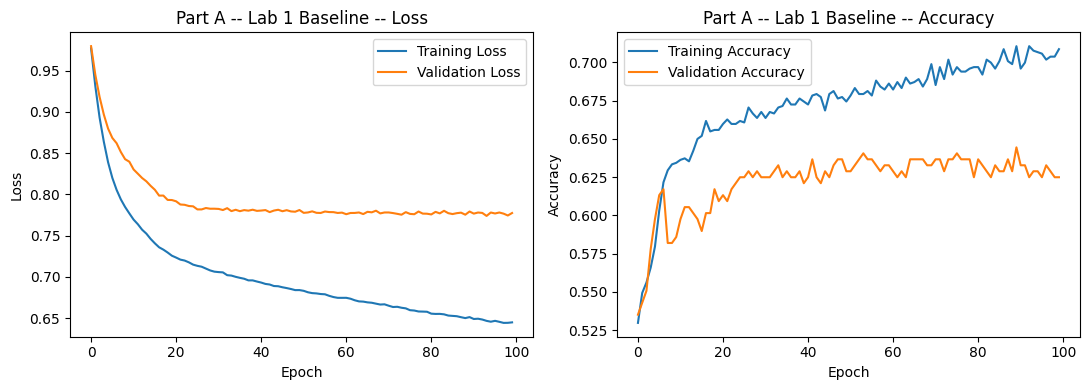

In [ ]:
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part A -- Lab 1 Baseline", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Original Lab 1 baseline test accuracy: 0.641


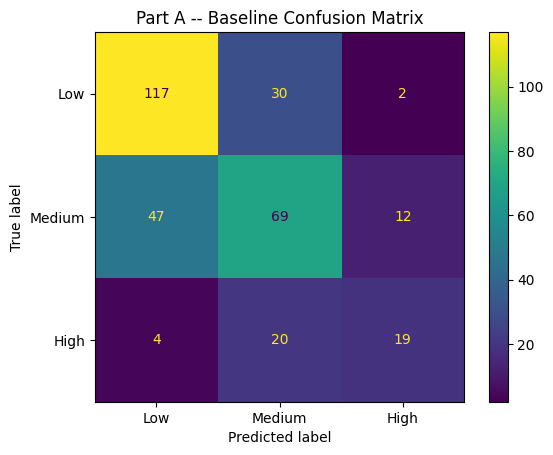

In [ ]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_baseline = accuracy_score(y3_test, multi_preds)
print(f"Original Lab 1 baseline test accuracy: {acc_baseline:.3f}")

cm_baseline = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm_baseline, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part A -- Baseline Confusion Matrix")
plt.show()

Part A Answer

For the baseline, we used the same Wine Quality model from Part 3 of Lab 1. We first changed the original wine scores into three groups: low, medium, and high. We did this because the assignment is a multiclass classification problem, so the model needed to predict one of three possible classes.

The baseline model had two hidden layers. The first layer had 16 neurons, and the second layer had 8 neurons. The output layer had 3 neurons because there were 3 quality groups. We used softmax because it gives a probability for each class. We used sparse categorical crossentropy because the class labels were numbers: 0, 1, and 2.

The original test accuracy is shown above in the notebook output. The loss curve showed overfitting. The training loss kept going down, but the validation loss stopped improving and stayed higher. This means the model was learning the training data too well, but it was not doing as well on new validation data.

Part B

For tuning, we tested three main settings: how many neurons were in the first hidden layer, how many neurons were in the second hidden layer, and the learning rate. These are important because they can change how well the model learns. The tuner used only the training data and a validation split to choose the best settings. We did not use the test set during tuning, so the final test result would still be fair.

In [ ]:
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu",
            input_shape=(n_features,)
        ),
        tf.keras.layers.Dense(
            hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [0.001, 0.01, 0.1])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
    directory="assignment1_tuning",
    project_name="wine_quality"
)

tuner.search(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=50,
    verbose=0
)

best_hp = tuner.get_best_hyperparameters(1)[0]
best_trial = tuner.oracle.get_best_trials(1)[0]

print("Best hyperparameters:")
print(best_hp.values)
print(f"Best validation loss from tuner: {best_trial.score:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best hyperparameters:
{'hidden1': 48, 'hidden2': 48, 'learning_rate': 0.001}
Best validation loss from tuner: 0.7518


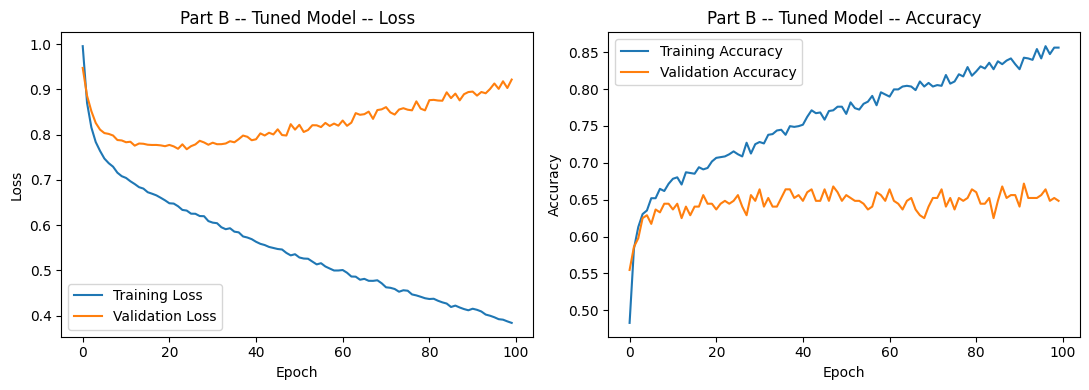

In [ ]:
final_tuned_model = build_model(best_hp)

history_tuned = final_tuned_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_tuned, "Part B -- Tuned Model", show_accuracy=True)

In [ ]:
tuned_probs = final_tuned_model.predict(X3_test_scaled)
tuned_preds = np.argmax(tuned_probs, axis=1)

acc_tuned = accuracy_score(y3_test, tuned_preds)
improvement = acc_tuned - acc_baseline

print(f"Baseline test accuracy: {acc_baseline:.3f}")
print(f"Tuned model test accuracy: {acc_tuned:.3f}")
print(f"Change from baseline: {improvement:.3f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Baseline test accuracy: 0.641
Tuned model test accuracy: 0.662
Change from baseline: 0.022


Part B answer

We used Keras Tuner to test different values for the two hidden layers and the learning rate. The tuner only used the training data with a validation split. This is important because the test set should not be used while choosing the best model.

The best settings and validation loss are printed above in the notebook. After tuning, we trained a new final model using those best settings. Then we tested it one time on the test set. The comparison printed above shows whether the tuned model did better than the original Lab 1 baseline and how much it changed.

Part C

To help fix the overfitting, we used the best settings from Part B and added Dropout and Early Stopping. Dropout helps the model not depend too much on the same neurons during training. Early Stopping stops the model when the validation loss is no longer improving. This helps prevent the model from training for too long and overfitting the training data.

In [ ]:
def build_regularized_model(best_hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            best_hp.get("hidden1"),
            activation="relu",
            input_shape=(n_features,)
        ),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(
            best_hp.get("hidden2"),
            activation="relu"
        ),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(best_hp.get("learning_rate")),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


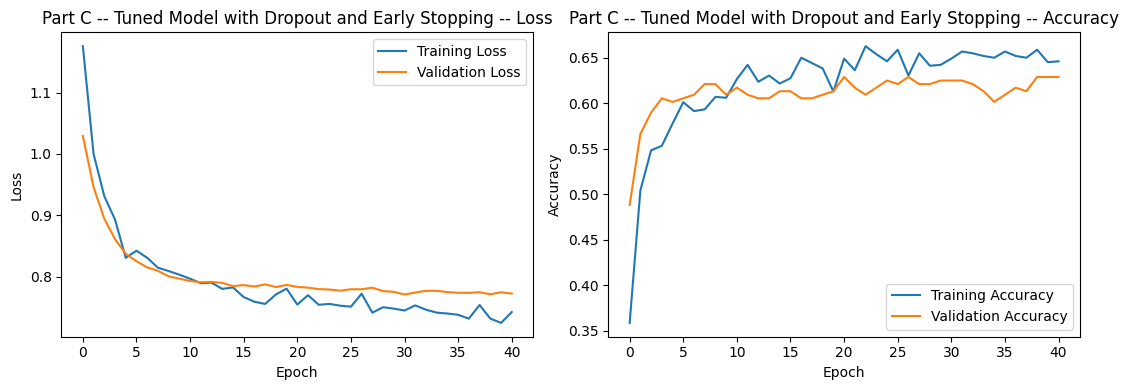

Epochs run before early stopping: 41


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

regularized_model = build_regularized_model(best_hp)

history_regularized = regularized_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

plot_history(history_regularized, "Part C -- Tuned Model with Dropout and Early Stopping", show_accuracy=True)
print("Epochs run before early stopping:", len(history_regularized.history["loss"]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Final regularized model test accuracy: 0.650


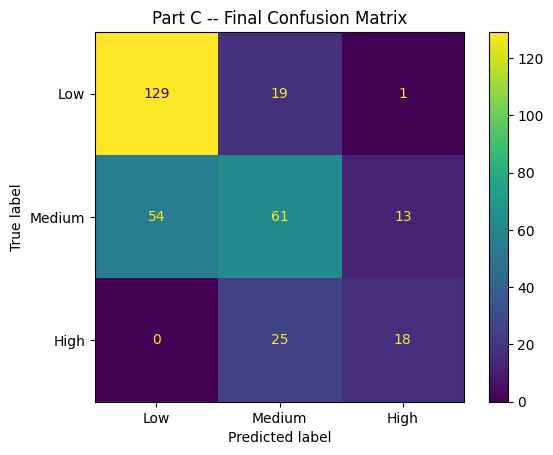

In [ ]:
regularized_probs = regularized_model.predict(X3_test_scaled)
regularized_preds = np.argmax(regularized_probs, axis=1)

acc_regularized = accuracy_score(y3_test, regularized_preds)
print(f"Final regularized model test accuracy: {acc_regularized:.3f}")

cm_regularized = confusion_matrix(y3_test, regularized_preds)
ConfusionMatrixDisplay(cm_regularized, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part C -- Final Confusion Matrix")
plt.show()

In [ ]:
def most_confused_pair(cm, labels):
    cm_copy = cm.copy()
    np.fill_diagonal(cm_copy, 0)
    row, col = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)
    return labels[row], labels[col], cm_copy[row, col]

labels = ["Low", "Medium", "High"]
base_from, base_to, base_count = most_confused_pair(cm_baseline, labels)
final_from, final_to, final_count = most_confused_pair(cm_regularized, labels)

print(f"Baseline most confused: {base_from} predicted as {base_to} ({base_count} times)")
print(f"Final model most confused: {final_from} predicted as {final_to} ({final_count} times)")

Baseline most confused: Medium predicted as Low (47 times)
Final model most confused: Medium predicted as Low (54 times)


Part C Answer

For Part C, we added Dropout and Early Stopping to the tuned model. Dropout helps reduce overfitting by making the model less dependent on the same neurons every time it trains. Early Stopping also helps because it stops training when the validation loss stops improving instead of forcing the model to keep training for all 200 epochs.

After retraining, we compared the new loss curve to the original Lab 1 curve. The main thing to check is whether the training loss and validation loss stayed closer together. The final test accuracy and confusion matrix are printed above in the notebook. The confusion matrix shows which classes are still being mixed up the most, and we can compare that to the original Lab 1 model to see if the mistakes changed.

Part D answers

It is important to save the test set until the very end because it is supposed to act like new data the model has not seen before. If we used the test set to choose the best hyperparameters, then the test results would not be a fair final score anymore. The model would already be influenced by that data.

Dropout and Early Stopping helped reduce overfitting by making the model train in a more controlled way. Dropout made the model less dependent on the same neurons, and Early Stopping stopped training when the validation loss stopped improving. The new loss curve can be compared to the Lab 1 curve by checking whether the training and validation loss stayed closer together and whether the validation loss stopped rising as much.

If we had more time and computing power, we could try more tuner trials, different layer sizes, different dropout rates, and class weights for the smaller high-quality wine class. We could also compare this neural network to other classification models to see if another model works better.